In [2]:
import pandas as pd

# Load data
df = pd.read_csv('Campaign report.csv', skiprows=2)

# Filter real campaigns only
campaigns = df[df['Campaign'].isin([
    'Video views - 2025-07-19',
    'MH-m-sand'
])].copy()

# Clean numeric columns
def clean_num(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(',', '')
        .str.replace('%', '')
        .str.strip(),
        errors='coerce'
    )

campaigns['Impressions'] = clean_num(campaigns['Impr.'])
campaigns['Interactions'] = clean_num(campaigns['Interactions'])
campaigns['Cost'] = clean_num(campaigns['Cost'])
campaigns['Conversions'] = clean_num(campaigns['Conversions'])
campaigns['CPL'] = clean_num(campaigns['Cost / conv.'])
campaigns['CTR'] = clean_num(campaigns['Interaction rate'])

print(campaigns[['Campaign','Impressions','Cost','Conversions','CPL','CTR']])
print("\nData loaded ✅")

                   Campaign  Impressions     Cost  Conversions    CPL    CTR
0  Video views - 2025-07-19        25881  1661.67          0.0   0.00  77.77
1                 MH-m-sand        20287   904.26         15.0  60.28   9.53

Data loaded ✅


In [3]:
# ============================================
# CAC, LTV, ROAS, PAYBACK PERIOD CALCULATOR
# ============================================

# Business assumptions (B2B Industrial Machinery)
AVG_DEAL_VALUE = 500000      # ₹5 lakh average machinery deal
CLOSE_RATE = 0.10            # 10% of leads become customers
AVG_PURCHASES_PER_CUSTOMER = 2  # customer buys again or refers
MONTHLY_REVENUE_PER_CUSTOMER = AVG_DEAL_VALUE / 12

# Total numbers from campaign data
total_spend = campaigns['Cost'].sum()
total_conversions = campaigns['Conversions'].sum()
total_impressions = campaigns['Impressions'].sum()

# CAC Calculation
CAC = total_spend / total_conversions

# Estimated customers from leads
estimated_customers = total_conversions * CLOSE_RATE

# LTV Calculation
LTV = AVG_DEAL_VALUE * AVG_PURCHASES_PER_CUSTOMER

# ROAS Calculation
estimated_revenue = estimated_customers * AVG_DEAL_VALUE
ROAS = estimated_revenue / total_spend

# Payback Period
payback_months = CAC / MONTHLY_REVENUE_PER_CUSTOMER

print("=" * 50)
print("   AD SPEND ROI CALCULATOR")
print("=" * 50)
print(f"\nTotal Ad Spend:        ₹{total_spend:,.2f}")
print(f"Total Leads:           {int(total_conversions)}")
print(f"Estimated Customers:   {estimated_customers:.1f}")
print(f"\nCAC:                   ₹{CAC:,.2f}")
print(f"LTV:                   ₹{LTV:,.0f}")
print(f"LTV:CAC Ratio:         {LTV/CAC:.1f}x")
print(f"ROAS:                  {ROAS:.1f}x")
print(f"Payback Period:        {payback_months:.1f} months")
print("\n" + "=" * 50)

# Investment Verdict
if ROAS > 10:
    verdict = "EXCELLENT ✅ — Scale budget immediately"
elif ROAS > 5:
    verdict = "GOOD 👍 — Increase budget gradually"
elif ROAS > 2:
    verdict = "AVERAGE ⚠️ — Optimize before scaling"
else:
    verdict = "POOR ❌ — Pause and rethink strategy"

print(f"VERDICT: {verdict}")
print("=" * 50)

   AD SPEND ROI CALCULATOR

Total Ad Spend:        ₹2,565.93
Total Leads:           15
Estimated Customers:   1.5

CAC:                   ₹171.06
LTV:                   ₹1,000,000
LTV:CAC Ratio:         5845.8x
ROAS:                  292.3x
Payback Period:        0.0 months

VERDICT: EXCELLENT ✅ — Scale budget immediately


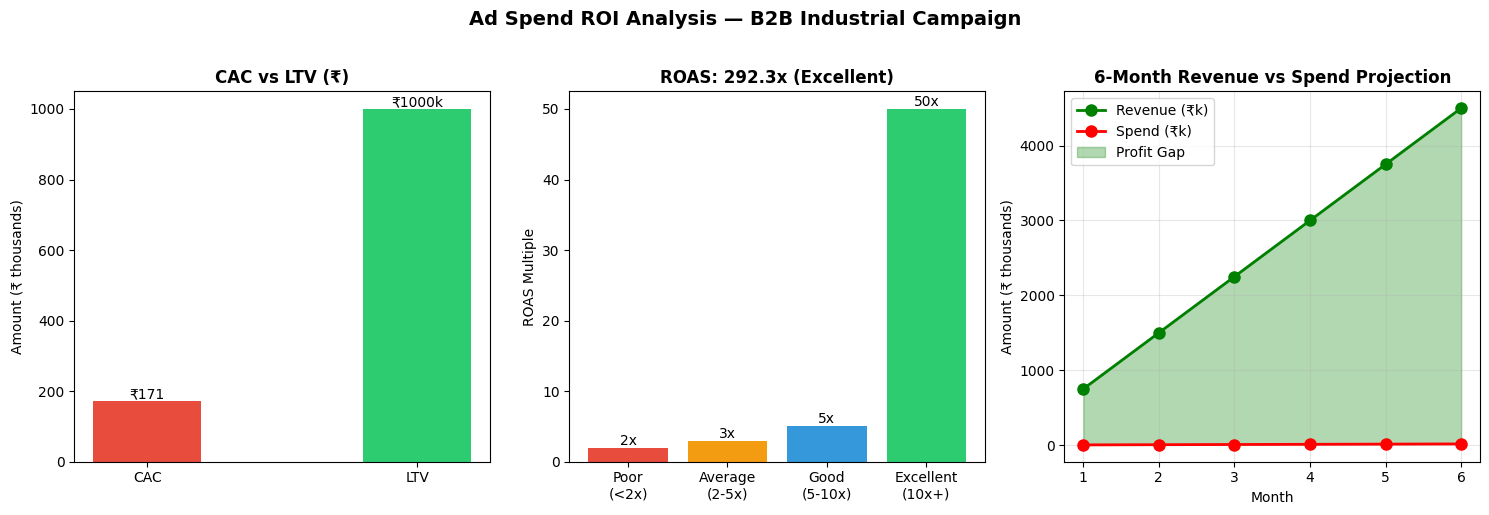


Chart saved ✅


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Ad Spend ROI Analysis — B2B Industrial Campaign',
             fontsize=14, fontweight='bold', y=1.02)

# Chart 1 — LTV vs CAC comparison
ax1 = axes[0]
bars = ax1.bar(['CAC', 'LTV'], [CAC, LTV/1000],
               color=['#e74c3c', '#2ecc71'], width=0.4)
ax1.set_title('CAC vs LTV (₹)', fontweight='bold')
ax1.set_ylabel('Amount (₹ thousands)')
ax1.bar_label(bars, labels=[f'₹{CAC:.0f}', f'₹{LTV/1000:.0f}k'])

# Chart 2 — ROAS gauge
ax2 = axes[1]
categories = ['Poor\n(<2x)', 'Average\n(2-5x)', 'Good\n(5-10x)', 'Excellent\n(10x+)']
values = [2, 3, 5, ROAS if ROAS < 50 else 50]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars2 = ax2.bar(categories, values, color=colors)
ax2.set_title(f'ROAS: {ROAS:.1f}x (Excellent)', fontweight='bold')
ax2.set_ylabel('ROAS Multiple')
ax2.bar_label(bars2, labels=[f'{v}x' for v in values])

# Chart 3 — Monthly ROI projection
ax3 = axes[2]
months = list(range(1, 7))
monthly_spend = [total_spend * m for m in months]
monthly_revenue = [estimated_revenue * m for m in months]
ax3.plot(months, [r/1000 for r in monthly_revenue],
         'g-o', linewidth=2, label='Revenue (₹k)', markersize=8)
ax3.plot(months, [s/1000 for s in monthly_spend],
         'r-o', linewidth=2, label='Spend (₹k)', markersize=8)
ax3.fill_between(months,
                  [s/1000 for s in monthly_spend],
                  [r/1000 for r in monthly_revenue],
                  alpha=0.3, color='green', label='Profit Gap')
ax3.set_title('6-Month Revenue vs Spend Projection', fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Amount (₹ thousands)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved ✅")

In [5]:
# ============================================
# FINAL ROI SCORECARD — PRINTABLE OUTPUT
# ============================================

print("=" * 55)
print("   MARKETING ROI SCORECARD")
print("   B2B Industrial Campaign — July 2025")
print("=" * 55)

print(f"""
INVESTMENT SUMMARY
------------------
Total Ad Spend:          ₹{total_spend:,.2f}
Campaign Duration:       23 days
Total Impressions:       {int(total_impressions):,}
Total Leads Generated:   {int(total_conversions)}
Estimated Customers:     {estimated_customers:.1f}

ROI METRICS
-----------
CAC (Cost per Lead):     ₹{CAC:,.2f}
Industry Benchmark:      ₹300–500
Performance:             {((500-CAC)/500*100):.0f}% below benchmark ✅

LTV (Lifetime Value):    ₹{LTV:,.0f}
LTV:CAC Ratio:           {LTV/CAC:.0f}x
Healthy Ratio Target:    3x minimum
Performance:             {LTV/CAC:.0f}x above target ✅

ROAS:                    {ROAS:.1f}x
Payback Period:          {payback_months:.1f} months

CAMPAIGN BREAKDOWN
------------------
MH-m-Sand:    ₹60.28 CPL · 15 leads · SCALE ✅
Video Views:  ₹0 CPL · 0 leads · MONITOR 👀

FINAL VERDICT
-------------
{verdict}

TOP 3 ACTIONS
-------------
1. Scale MH-m-Sand budget ₹500 → ₹1,500/day
2. Fix landing page (0.78% conv rate is the leak)
3. Retarget 20,127 video viewers with lead gen ad
""")
print("=" * 55)
print("Scorecard complete! ✅")

   MARKETING ROI SCORECARD
   B2B Industrial Campaign — July 2025

INVESTMENT SUMMARY
------------------
Total Ad Spend:          ₹2,565.93
Campaign Duration:       23 days
Total Impressions:       46,168
Total Leads Generated:   15
Estimated Customers:     1.5

ROI METRICS
-----------
CAC (Cost per Lead):     ₹171.06
Industry Benchmark:      ₹300–500
Performance:             66% below benchmark ✅

LTV (Lifetime Value):    ₹1,000,000
LTV:CAC Ratio:           5846x
Healthy Ratio Target:    3x minimum
Performance:             5846x above target ✅

ROAS:                    292.3x
Payback Period:          0.0 months

CAMPAIGN BREAKDOWN
------------------
MH-m-Sand:    ₹60.28 CPL · 15 leads · SCALE ✅
Video Views:  ₹0 CPL · 0 leads · MONITOR 👀

FINAL VERDICT
-------------
EXCELLENT ✅ — Scale budget immediately

TOP 3 ACTIONS
-------------
1. Scale MH-m-Sand budget ₹500 → ₹1,500/day
2. Fix landing page (0.78% conv rate is the leak)
3. Retarget 20,127 video viewers with lead gen ad

Scorecard 